# Preliminary Analysis for TriDENT

## Characterizing the activation during training
- UCI Iris dataset.
- Model checkpointed at various points during training.
- Plot the distribution of inputs in the hidden layer and corresponding distributions of activations (-1, 0, +1).


In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary
from models import TernaryStochasticActivation, DualSampleTernary

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')

today = date.today().isoformat()

In [ ]:
# Path for loading the models: UPDATE BASED ON MACHINE
MODEL_PATH = "/local_disk/vikrant/trident/models"
FIGURES_PATH = "../plots/"

In [3]:
# load all the models into a list
models_list = glob.glob(os.path.join(MODEL_PATH, "ffn_uci*"))
print(models_list)

# print out the trained model
with open(models_list[-1], "rb") as f:
    dummy_model = pickle.load(f)

print(dummy_model['configs'])
print(dummy_model['state'])

['/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_0.pkl', '/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_5000.pkl', '/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_10000.pkl', '/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_15000.pkl', '/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_19999.pkl']
{'train_steps': 20000, 'eval_every': 1000, 'learning_rate': 0.0001, 'threshold': 0.0, 'noise_std': 0.01, 'layers': [4, 32, 3], 'seed': 234}
State({
  'activation': {
    'rngs': {
      'activation': {
        'count': RngCount( # 1 (4 B)
          value=Array(20019, dtype=uint32),
          tag='activation'
        ),
        'key': RngKey( # 1 (8 B)
          value=Array((), dtype=key<fry>) overlaying:
          [

In [4]:
class CustomLinear(nnx.Module):

    def __init__(self,
                 rngs: nnx.Rngs = nnx.Rngs(0),
                 threshold: float = 0.0,
                 noise_std: float = 1.0,
                 noise_mean: float = 0.0,
                 ):
        self.rngs = rngs
        self.threshold = threshold
        self.noise_std = noise_std
        self.noise_mean = noise_mean
        
    def __call__(self, x):
        return x


cl = CustomLinear()
cl(10)

10

In [5]:
# defining the model
class FFN(nnx.Module):

    def __init__(
            self,
            rngs: nnx.Rngs,
            layers: list[int],
            noise_std: float = 0.5,
            threshold: float = 0.0,
            ActivationFunction: nnx.Module = DualSampleTernary,
            **kwargs):
        
        self.activation = ActivationFunction(threshold=threshold, noise_std=noise_std, rngs=rngs)

        self.layers = nnx.List([
            nnx.Linear(in_features=li, out_features=lo, rngs=rngs) for li, lo in zip(layers[:-1], layers[1:])
        ])
    
    def __call__(self, x):

        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

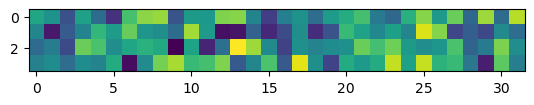

In [6]:
# trial load model
seed = dummy_model['configs']['seed']
rngs = nnx.Rngs(
    params=seed + 0,
    dropout=seed + 1,
    activation=seed + 2,
    next = seed + 3 
    )

model = FFN(
    layers=dummy_model['configs']['layers'],
    noise_std=dummy_model['configs']['noise_std'],
    threshold=dummy_model['configs']['threshold'],
    activation_function=CustomLinear,
    rngs=rngs
)



graphdef_untrained, _ = nnx.split(model)
model = nnx.merge(graphdef_untrained, dummy_model['state'])
nnx.display(model)

# print(model.layers[1].kernel.get_value())
plt.imshow(model.layers[0].kernel.get_value(), cmap='viridis')

del model

In [7]:
# ------------------------------------
# Import UCI 
# ------------------------------------
def load_uci_iris(
        key: int = 0,
        train_test_split: float = 0.8,
        normalize: bool = True, # normalize the data to
        **kwargs):
    data = load_iris()

    X = jnp.array(data['data'])
    y = jnp.array(data['target'])

    # feature-wise normalization [0, 1]
    if normalize:
        Xmin = X.min(axis=0)  
        Xmax = X.max(axis=0)
        X = (X - Xmin) / (Xmax - Xmin + 1e-8)

    # split the dataset into train and test sets: TODO
    # shuffle the data
    key = jax.random.key(key)
    random_permutation = jax.random.permutation(key, X.shape[0])
    X = X[random_permutation]
    y = y[random_permutation]

    # split the data
    split_index = jnp.floor(train_test_split * X.shape[0]).astype(int)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"Size of training data {X_train.shape}, size of test data {X_test.shape}")



    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_uci_iris(normalize=True, key=101, train_test_split=1)


Size of training data (150, 4), size of test data (0, 4)


In [123]:
## plotting a trial run of the inference model

# linear model
linear_model = FFN(
    layers=dummy_model['configs']['layers'],
    noise_std=dummy_model['configs']['noise_std'],
    threshold=dummy_model['configs']['threshold'],
    activation_function=CustomLinear,
    rngs=rngs
)

# trident model
trident_model = FFN(
    layers=dummy_model['configs']['layers'],
    noise_std=dummy_model['configs']['noise_std'],
    threshold=dummy_model['configs']['threshold'],
    activation_function=DualSampleTernary,
    rngs=rngs
)

# initialize containers to store the activations
logits_ = jnp.zeros((len(models_list), X_train.shape[0], 32))
activations_ = jnp.zeros((len(models_list), X_train.shape[0], 32))


for idx, model_name in enumerate(models_list):
    print(model_name, idx)

    # load the trained model
    with open(model_name, "rb") as f:
        model_config_state = pickle.load(f)

    # dump the trained state in the linear model
    graphdef_l, _ = nnx.split(linear_model)
    linear_model = nnx.merge(graphdef_l, model_config_state['state'])

    # dump trained state in the trident model
    graphdef_t, _ = nnx.split(trident_model)
    trident_model = nnx.merge(graphdef_t, model_config_state['state'])

    # iterate over the dataset and collect hidden layer activations
    # for linear model
    logits = linear_model.layers[0](X_train)
    activations = trident_model.activation(linear_model.layers[0](X_train))

    # collect the activations in their containers
    logits_ = logits_.at[idx, ...].set(logits)
    activations_= activations_.at[idx, ...].set(activations)

    # for i, axs in enumerate(ax.ravel()):
    #     sns.histplot(logits[:, i], ax=axs, color=grey_pal[idx], alpha=0.8, kde=True)
    #     sns.histplot(activations[:, i], ax=axs, color=rocket_pal[idx], alpha=0.3)
    #     axs.set_xlim(-1.01, 1.01)
    #     axs.set_ylim(0, 150)
    
del linear_model
del trident_model
del logits
del activations


/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_0.pkl 0
/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_5000.pkl 1
/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_10000.pkl 2
/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_15000.pkl 3
/local_disk/vikrant/trident/models/ffn_uci_iris_hidden_date_2026-05-04_32_noise_0.01_threshold_0.0_step_19999.pkl 4


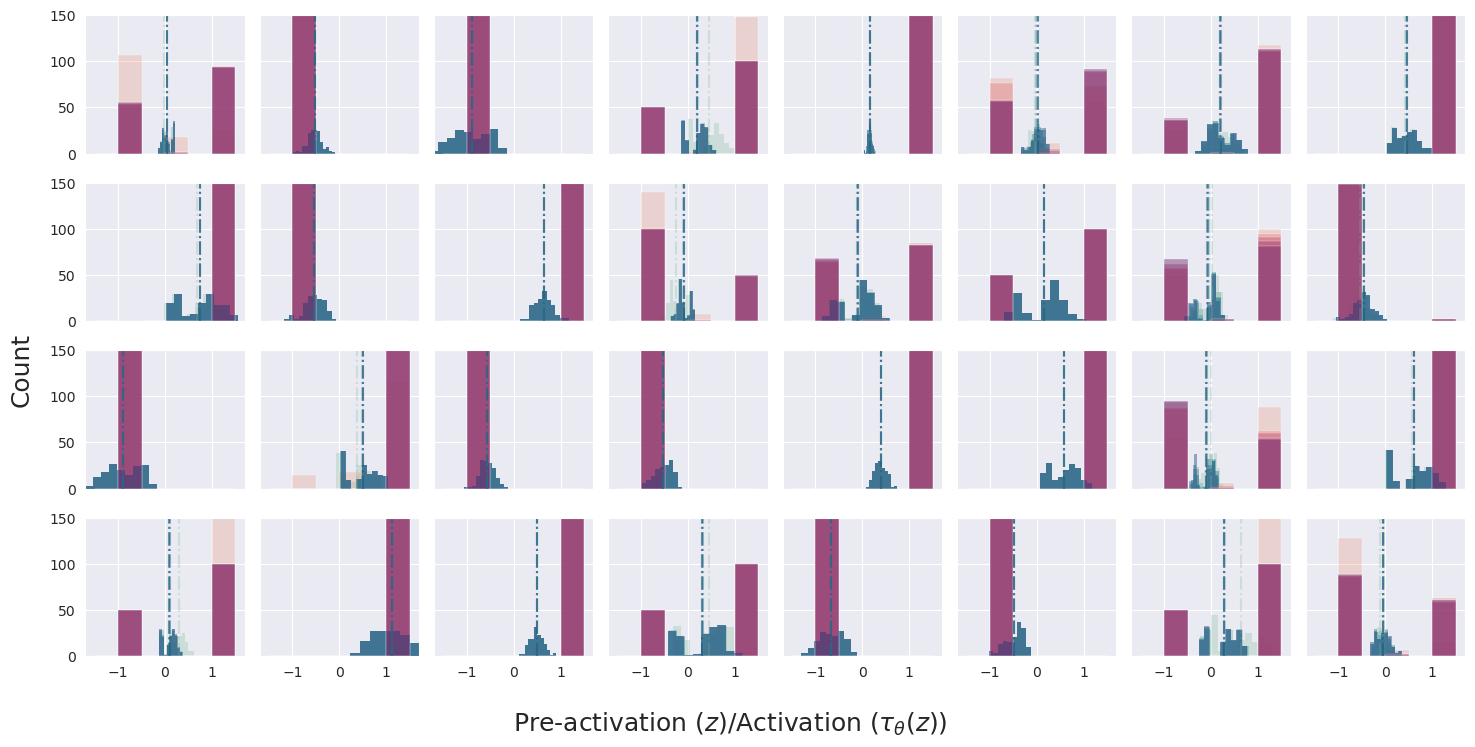

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(15, 7.5), sharex=True, sharey=True)

sns.set_style("darkgrid")
logits_pal = sns.color_palette("crest", len(models_list))
activations_pal = sns.color_palette("flare", len(models_list))
bins_arr = [-1.5, -1, -0.5, 0, 0.5, 1, 1.5]
stat_str = 'count'

for e in range(len(models_list)):
    for i, axs in enumerate(ax.ravel()):

        # dynamic alpha: let is got from 0.15 -> 0.75
        min_alpha = 0.25
        max_alpha = 0.5
        alpha_ = min_alpha + (max_alpha - min_alpha) * e / len(models_list)

        sns.histplot(logits_[e, :, i], 
                     ax=axs, 
                     color=logits_pal[e], 
                     alpha=alpha_, 
                    #  kde=True,
                     edgecolor=None,
                     linewidth=0,
                     stat=stat_str,
                    #  bins=bins_arr,
                    #  kde_kws={'alpha': alpha_},
                    #  line_kws={'linewidth': alpha_*2}
                     )
        axs.axvline(x=jnp.mean(logits_[e, :, i]), color=logits_pal[e], alpha=alpha_, linestyle="-.")

        sns.histplot(activations_[e, :, i], 
                     ax=axs, 
                     color=activations_pal[e], 
                     alpha=alpha_,
                     edgecolor=None,
                     linewidth=0.2,
                     bins = bins_arr,
                    #  binrange=(-1, 1),
                     stat=stat_str
                     )
        
        

        axs.set_xlim(-1.7, 1.7)
        # axs.set_ylim(0, 5)
        axs.set_ylim(0, 150)
        axs.set_ylabel("")

        # sns.despine(ax=axs, offset=10, trim=True)
# plt.text(x=10, y=10, s="Count", ha='center', va='center', fontsize=18)
fig.supylabel("Count", fontsize=18)
fig.supxlabel(r"Pre-activation ($z$)/Activation ($\tau_\theta(z)$)", fontsize=18)
plt.tight_layout(rect=[0.01, 0.01, 1, 1])

# fig.savefig(os.path.join(FIGURES_PATH, f"uci_iris_activation_during_learning_{today}.png"), dpi=300, bbox_inches='tight')

In [36]:
logits_[0, ...]

Array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)